In [14]:
# Numerical computations
import numpy as np

# Data handling
import pandas as pd

# Plotting graphs
import matplotlib.pyplot as plt

# Used to scale data
from sklearn.preprocessing import StandardScaler

# DBSCAN algorithm
from sklearn.cluster import DBSCAN

# Used to evaluate clustering quality
from sklearn.metrics import silhouette_score

In [15]:
np.random.seed(42)

# Cluster 1
income1 = np.random.normal(2000, 200, 100)
spend1 = np.random.normal(20, 5, 100)

# Cluster 2
income2 = np.random.normal(5000, 300, 100)
spend2 = np.random.normal(50, 5, 100)

# Cluster 3
income3 = np.random.normal(9000, 400, 100)
spend3 = np.random.normal(80, 5, 100)

# Combine all groups
income = np.concatenate([income1, income2, income3])

spending = np.concatenate([spend1, spend2, spend3])

# Create dataframe
X_data = pd.DataFrame({
    "Annual income": income,
    "Spending score": spending
})

# Creating Noise
noise = np.random.uniform(
    low=[0, 0],
    high=[12000, 100],
    size=(20, 2)
)

X_array = X_data.values

X_full = np.vstack([X_array, noise])


X = pd.DataFrame(X_full, columns=["Annual Income", "Spending Score"])
print(df.head())


   Annual Income  Spending Score
0    1906.424698       13.553224
1    2335.675803       22.742358
2    1843.640270       17.715949
3    1835.943560       14.485058
4    2314.506846       29.633681


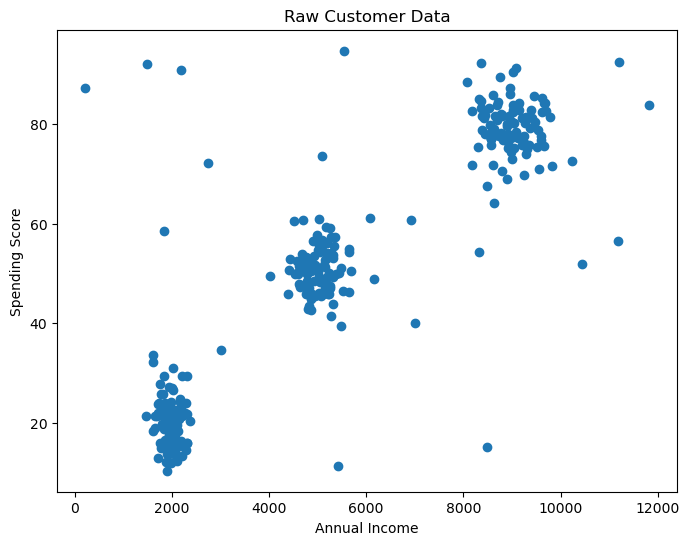

In [16]:
plt.figure(figsize = (8, 6))
plt.scatter(
    X["Annual Income"],
    X["Spending Score"]
)

plt.xlabel("Annual Income")
plt.ylabel("Spending Score")
plt.title("Raw Customer Data")
plt.show()

In [28]:
# Scaling the data
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)



In [29]:
# Train model
model = DBSCAN(
    eps = 0.5,
    min_samples = 5
)

clusters = model.fit_predict(X_scaled)



In [34]:
# Forming clusters
X["Cluster"] = clusters

print(X.head())
print(X["Cluster"].value_counts())

   Annual Income  Spending Score  Cluster
0    2099.342831       12.923146        0
1    1972.347140       17.896773        0
2    2129.537708       18.286427        0
3    2304.605971       15.988614        0
4    1953.169325       19.193571        0
Cluster
 1    103
 2    103
 0    101
-1     13
Name: count, dtype: int64


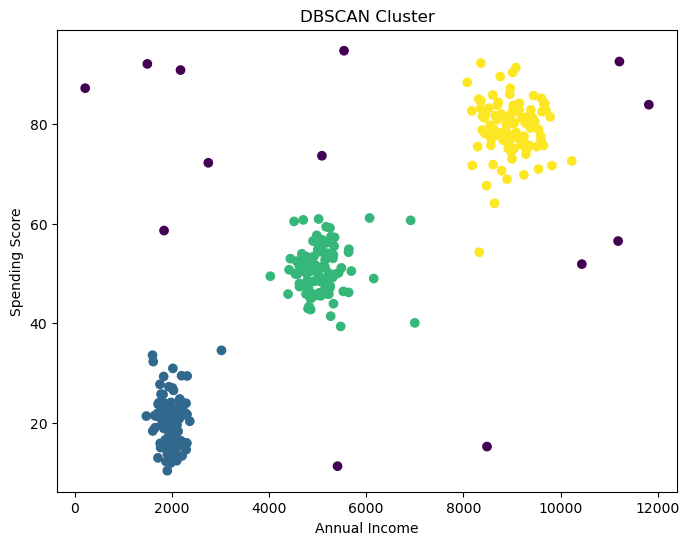

In [35]:
plt.figure(figsize = (8, 6))
plt.scatter(
    X["Annual Income"],
    X["Spending Score"],
    c = X["Cluster"]
)

plt.xlabel("Annual Income")
plt.ylabel("Spending Score")
plt.title("DBSCAN Cluster")

plt.show()

In [36]:
# Evaluating the model

filtered_data = X_scaled[X["Cluster"] != -1]

filtered_labels = X[X["Cluster"] != -1]["Cluster"]

score = silhouette_score(
    filtered_data,
    filtered_labels
)

print("Silhouette Score:", score)

Silhouette Score: 0.8227869555171531
